<a href="https://colab.research.google.com/github/Racim-dev/Interactive-Interface/blob/main/TP3_2026.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np

## 1) Dynamic Programming

Let $\mathcal{X} = \{0,1,2,3\}$,  $\mathcal{A} = \{0,1\}$.
    Let $(X_t)_{t \in \{1, \dots ,5 \}}$ be a controlled Markov chain, such that,
    if $a=0$, it stays in its state, and if $a=1$ it has a probability $0.5$ of going $1$ up
    (if possible, otherwise stay in place),
    and $0.5$ of going $1$ down (if possible, otherwise stay in place).
    
Solve by Dynamic Programming the following optimization problem.
$$ \min \mathbb{E}[\sum_{t=1}^{5} X_t^2 \; | \; X_0 = 3]$$

In [2]:
def cost(x):
    return x**2

T = 5 # Horizon temporel
N = 4 # Nombre d'etats

P1 = np.array([[0.5, 0.5, 0, 0],[0.5, 0, 0.5, 0],[0, 0.5, 0, 0.5],[0, 0, 0.5, 0.5]]) # matrice de transition pour controle a = 1
P0 = np.eye(4) # (matrice identite) matrice de transition pour controle a = 0
# En pratique ci dessous on code directement les transitions sans utiliser la valeur de ces matrices

V = np.zeros([N,T + 1]) # V[x,t] = cout optimal en étant à l'instant t en position x
Phi = np.zeros([N,T]) # Phi[x,t] = stratégie optimale en étant à l'instant t en position x

# Initialisation (en commançant par la fin)
for i in range(0,N):
    V[i,T] = cost(i) # Condition de terminaison

for j in range(T-1,-1,-1): # On commence par l'avant-dernier temps et on remonte
    for i in range(0,N):
        V[i,j] = cost(i) + min(V[i,j+1], 0.5*V[ max(0,i-1), j+1] + 0.5*V[ min(3,i+1), j+1]) # Cout optimal
        Phi[i,j] = np.argmin([V[i,j+1], 0.5*V[ max(0,i-1), j+1] + 0.5*V[ min(3,i+1), j+1]]) # Controle optimal

print("Cout optimal : \n", V, "\n")
print(" Stratégie optimale : \n", Phi)
print("Pour répondre à la question, la valeur optimale est donc : ",V[3,0])

Cout optimal : 
 [[ 0.       0.       0.       0.       0.       0.     ]
 [ 6.       5.       4.       3.       2.       1.     ]
 [21.3125  18.6875  15.875   12.       8.       4.     ]
 [33.15625 29.625   25.375   20.75    15.5      9.     ]] 

 Stratégie optimale : 
 [[0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0.]
 [1. 1. 1. 0. 0.]
 [1. 1. 1. 1. 1.]]
Pour répondre à la question, la valeur optimale est donc :  33.15625


## 2) Maintenance

We consider a company that operates numerous vending machines.
A machine can be new, in good shape, old or broken.
Each month you can either do nothing (cost $0$), maintain (cost $10$), repair (cost $15$ if in good shape, $30$ if old, $50$ if broken) or replace (cost $70$) a machine.
A repaired machine will be in good shape at the end of the month.
A replaced machine will be new at the end of the month.
No action can be taken on a new machine and it will be in good shape at the end of the month.
Without maintenance (resp. with maintenance), a machine in good shape will be in good shape at the end of the month with probability $0.3$ (resp. $0.8$) and old with probability $0.7$ (resp. $0.2$).
Without maintenance (resp. with maintenance), a machine in old shape will be in old shape at the end of the month with probability $0.5$ (resp. $0.9$) and broken with probability $0.5$ (resp. $0.1$).
A broken machine will stay broken unless it is repaired or replaced.

A new machine earns $30$, a machine in good shape earns $20$, an old one earns $10$
and a broken machine earns $0$ for the month.

Questions:

-Describe the problem in terms of a controlled Markov Chain.

-Solve the problem using Dynamic Programming: write a function that returns the optimal policy and the expected cost associated with this policy.

-(Bonus) Simulate the optimal policy and check with Monte-Carlo simulation that the optimal value is indeed obtained.

Il y a une subtilité : pour interdire les transitions dans le cas "new" pour des actions autres que "nothing". On le fait via la matrice de coûts et la valeur infinie.

Ici le coût est de la forme $c(u,x_t)$ et ne dépend pas de $x_{t+1}$ (noté $y$ dans le cours) donc on peut le sortir de la somme sur $y$ des P^u(x,y). Assigner un coût infini $c(u,x_t)$ interdit le mouvement correspondant. Par ailleurs la fonction valeur ne vaut jamais $-\infty$, donc on ne fait jamais de multiplication prohibée.

De manière générale, on peut mettre n'importe quelle valeur P^u(x,y)>0 pour les mouvements interdits du moment qu'on ajoute un coût infini à ces mouvements.

A noter `np.dot(P3[i,:],V[:,t+1]) - c[3,i]` devient `np.dot(P3[i,:],V[:,t+1]- c[3,i,:])` pour un coût de la forme $c(u,x_t,x_{t+1})$.


In [3]:
#Paramètre du problème
T=12
Inf = 10**(9) # modélise l'infini
états = ["broken","old","good shape","new"]
actions = ["nothing","maintain","repair","replace"]

# matrice de transion pour "nothing"
P0 = np.array([[ 1., 0., 0., 0.],
                [ 0.5, 0.5 , 0., 0.],
                [ 0., 0.7, 0.3, 0.],
                [ 0., 0., 1., 0.]])

# matrice de transition pour "maintain"
P1 = np.array([[ 0., 0. , 0, 0], # this action is not possible
                [ 0.1, 0.9, 0., 0],
                [ 0, 0.2, 0.8, 0.],
                [ 0, 0, 0, 0.]]) # this action is not possible

# matrice de transition pour "repair"
P2 = np.array([[ 0., 0., 1., 0],
                [ 0., 0, 1., 0],
                [ 0., 0., 1., 0.],
                [ 0., 0., 0., 0.]]) # this action is not possible

# matrice de transition pour "replace"
P3 = np.array([[ 0., 0., 0., 1.],
                [ 0., 0., 0., 1.],
                [ 0., 0., 0., 1.],
                [ 0, 0, 0, 0.]]) # this action is not possible

r = np.array([0,10,20,30]) # reward for each state

c = np.array([[ 0.,0.,0.,0.], # do nothing cost
            [Inf, 10., 10., Inf], # maintenance cost
            [50., 30., 15., Inf], # repair cost
            [70, 70, 70, Inf]])   # replace cost

V = np.zeros((4,T))
pi = np.zeros((4,T-1),int)

Valeur optimale : 
 [[ 35.82  30.82  25.82  20.82  15.82  10.82   5.82   0.4    0.     0.
    0.     0.  ]
 [ 60.82  55.82  50.82  45.82  40.82  35.82  30.82  25.82  20.4   17.5
   15.    10.  ]
 [ 85.82  80.82  75.82  70.82  65.82  60.82  55.82  50.82  45.82  40.4
   33.    20.  ]
 [110.82 105.82 100.82  95.82  90.82  85.82  80.82  75.82  70.4   63.
   50.    30.  ]] 

 Politique optimale : 
 [[3 3 3 3 3 3 3 3 0 0 0]
 [2 2 2 2 2 2 2 2 2 0 0]
 [1 1 1 1 1 1 1 2 1 0 0]
 [0 0 0 0 0 0 0 0 0 0 0]]


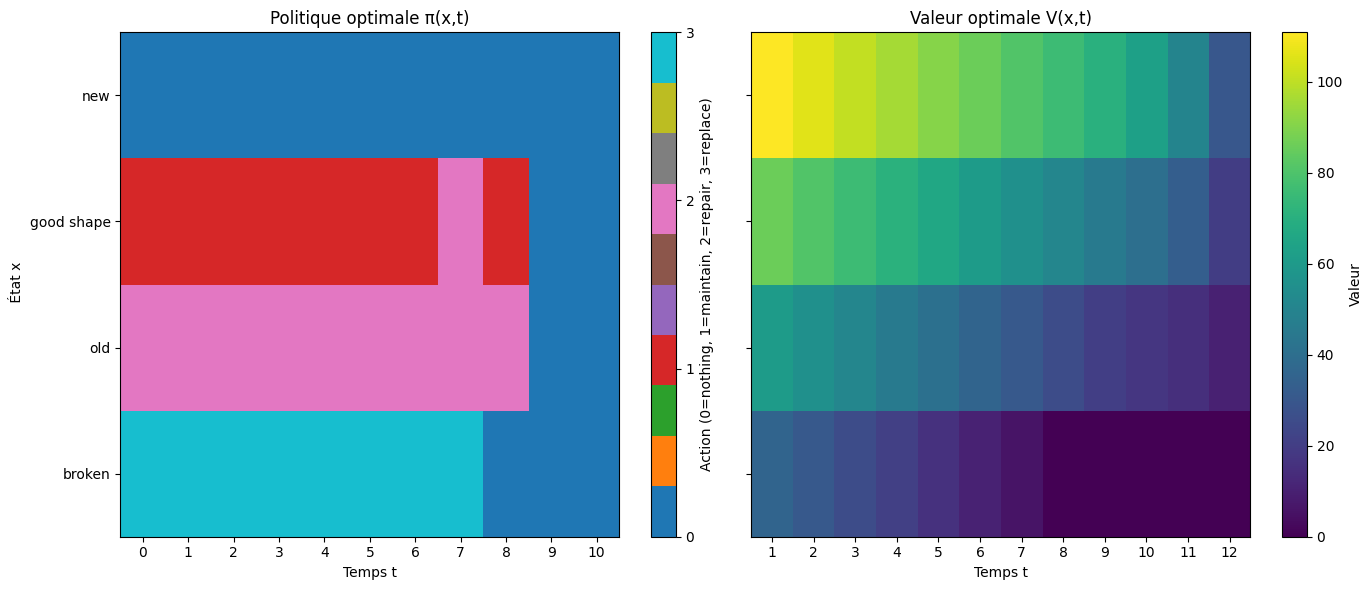

In [4]:
#Initialisation
V[:,T-1] = r # Gain à la fin du mois T

#Itération
for t in range(T-2,-1,-1):
    for i in range(4):
        Q = [r[i] + np.dot(P0[i,:],V[:,t+1]) - c[0,i], # gain du mois t + cout de passage à t+1
            r[i] + np.dot(P1[i,:],V[:,t+1]) - c[1,i],
            r[i] + np.dot(P2[i,:],V[:,t+1]) - c[2,i],
            r[i] + np.dot(P3[i,:],V[:,t+1]) - c[3,i]]
        V[i,t] = max(Q)
        pi[i,t] = np.argmax(Q)
        #ici Q représente Q_t(x,.) de taille 4 (où 4 est le nombre de contrôles).
print("Valeur optimale : \n", V, "\n")
print(" Politique optimale : \n", pi)

# Visualisation de la politique optimale et de la valeur optimale

import matplotlib.pyplot as plt
pi_plot = pi
V_plot = V
fig, (ax0, ax1) = plt.subplots(1, 2, figsize=(14, 6), sharey=True)
# Graphe de la politique optimale
im0 = ax0.imshow(pi_plot, origin="lower", aspect="auto", cmap="tab10")
ax0.set_xlabel("Temps t")
ax0.set_ylabel(" État x")
ax0.set_title("Politique optimale π(x,t)")
ax0.set_xticks(range(T-1))
ax0.set_xticklabels(range(T-1))
ax0.set_yticks(range(len(états)))
ax0.set_yticklabels(états)  # On affiche les états à partir de "old"
cbar0 = fig.colorbar(im0, ax=ax0, ticks=range(len(états)))
cbar0.set_label("Action (0=nothing, 1=maintain, 2=repair, 3=replace)")
# Graphe de la valeur optimale
im1 = ax1.imshow(V_plot, origin="lower", aspect="auto", cmap="viridis")
ax1.set_xlabel("Temps t")
ax1.set_title("Valeur optimale V(x,t)")
ax1.set_xticks(range(V_plot.shape[1]))
ax1.set_xticklabels(range(1, V_plot.shape[1] + 1))
cbar1 = fig.colorbar(im1, ax=ax1)
cbar1.set_label("Valeur")
plt.tight_layout()
plt.show()


Version alternative sans utiliser les matrices de transition P^u, en faisant les calculs directement à la main.

In [5]:
#Problem parameters
T=12

states = ["broken","old","good shape","new"]
actions = ["nothing","maintain","repair","replace"]

p1 = 0.3 #staying GS if not maintained
p2 = 0.8 #staying GS if maintained
p3 = 0.5 #staying O if not maintained
p4 = 0.9 #staying O if maintained

r = [0,10,20,30]# reward
c_m = [Inf, 10, 10, Inf] #maintenance cost
c_repaired = [50, 30, 15, Inf] #repair cost
c_replaced = 70
selling_value = [0, 0, 0, 0]

V = np.zeros((4,T+1))
pi = np.zeros((4,T),dtype=int);

In [6]:
def DP_step(V,pi,t):
    for i in range(0, 4):
        if i == 0: #broken
            Q_n = r[i]+V[0,t+1]
            Q_m = float('-inf')   #no maintenance possible

        elif i==1: #old
            Q_n = r[i]+p3*V[1,t+1]+(1-p3)*V[0,t+1]
            Q_m = r[i]+p4*V[1,t+1]+(1-p4)*V[0,t+1] - c_m[i]

        elif i==2: #good shape
            Q_n = r[i]+p1*V[2,t+1]+(1-p1)*V[1,t+1]
            Q_m = r[i]+ p2*V[2,t+1]+(1-p2)*V[1,t+1] - c_m[i]
        else: #new
            Q_n = r[i]+V[2,t+1]
            Q_m = float('-inf')
        Q_repaired = r[i]+ V[2,t+1] - c_repaired[i]
        Q_replaced = r[i]+ V[3,t+1] - c_replaced

        #println("t=",t," i=",i, " [Q_n, Q_m, Q_repaired, Q_replaced]=",[Q_n, Q_m, Q_repaired, Q_replaced])
        V[i,t]  = max([Q_n, Q_m, Q_repaired, Q_replaced])
        pi[i,t] = np.argmax([Q_n, Q_m, Q_repaired, Q_replaced])

def DP(V,pi):
    V[:,T]=selling_value
    for t in range(T - 1, -1, -1):
        DP_step(V,pi,t)

DP(V,pi)
pi

array([[3, 3, 3, 3, 3, 3, 3, 3, 0, 0, 0, 0],
       [2, 2, 2, 2, 2, 2, 2, 2, 2, 0, 0, 0],
       [1, 1, 1, 1, 1, 1, 1, 2, 1, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]])

## 3) Stock management

We consider a shop that has a stock of a single product that should stay between $1$ and $20$. Each evening the vendor can order for the next morning up to $5$ products at a price of $1$ per item. Furthermore, the total stock (current stock + order) cannot exceed $20$.
Having a stock $x$ at the end of the day costs $0.1x$ to the owner.
During the day $t$ he can sell products up to $d_t$ for a price of $3$ per item, where $d_t$ is a random demand. Unmet demand is lost. After $T = 14$  the stock is lost.
We start with an initial stock of $10$ products.

The demands $d_t$ are stochastically independent binomials of parameter $(p_t,n)$ where
p = [0.2 0.2 0.4 0.4 0.7 0.7 0.2 0.2 0.8 0.8 0.5 0.5 0.2 0.2]
and $n = 10$.


Questions:

-Describe the problem in terms of a stochastic control problem. (state, action, cost, transition probability, $\dots$)

-Solve the problem using Dynamic Programming: write a function that returns the optimal policy and the expected cost associated with this policy.

-(Bonus) Simulate the optimal policy and check with Monte-Carlo simulation that the optimal value is indeed obtained.

Valeur optimale : 
 [[109.15585178 105.00255621  98.59536248  89.49298305  79.93997925
   70.0640611   60.25022939  52.62268246  43.20716961  33.30834796
   23.41751029  14.50965164   5.90199889   2.40213016   0.        ]
 [110.15585178 106.39614167 100.88499042  92.12171857  82.87073158
   72.84048717  61.97605651  55.28079522  46.20146224  36.26615797
   25.32688751  16.19700927   6.90199889   3.40213016   0.        ]
 [111.15585178 107.58095643 102.89199328  94.52449575  85.6826149
   75.30052111  63.4013264   57.73581028  49.17808977  39.10537511
   26.78713251  17.4340957    7.90199889   4.40213016   0.        ]
 [112.15585178 108.61858585 104.61640152  96.64746408  88.27724467
   77.3025126   64.58187533  59.90818546  52.1049262   41.65617816
   27.93107941  18.4340957    8.90199889   5.30095162   0.        ]
 [113.15585178 109.61858585 106.07744495  98.46032092  90.55817507
   78.83733774  65.6033487   61.74108682  54.92358435  43.72533958
   28.93107941  19.4340957    9.9019988

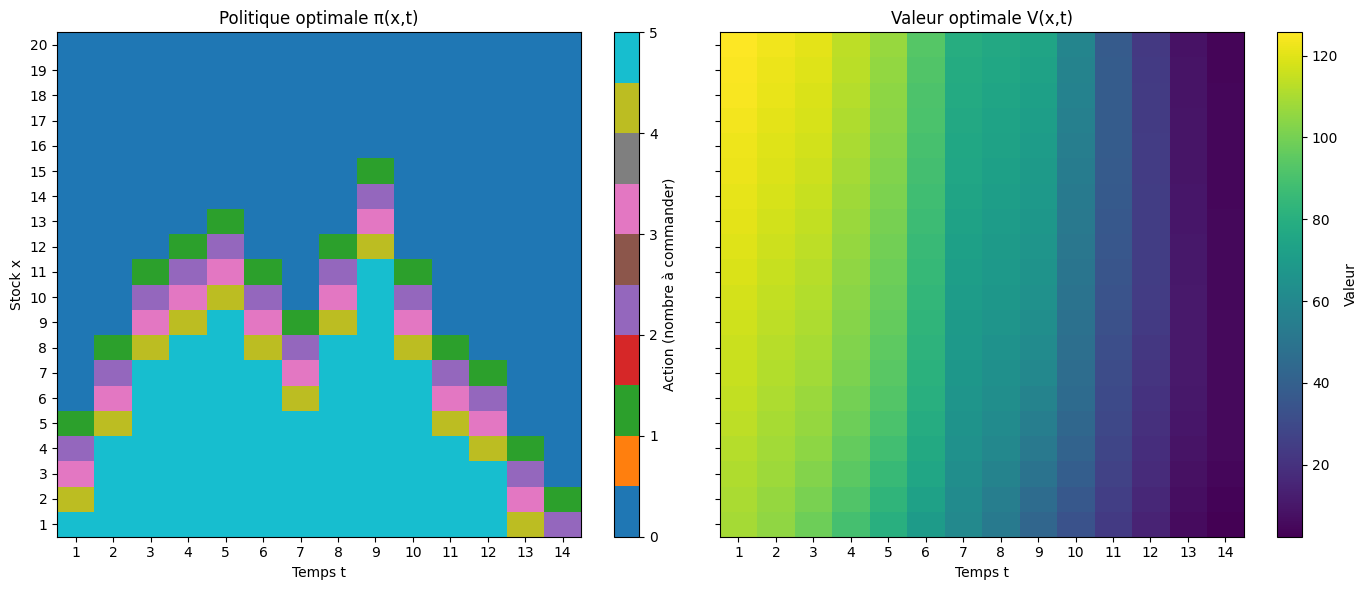

In [7]:
import math

n = 10
T = 14
S = 20
Inf = 10**9
holding_cost = 0.1
stock_price = 1
sell_price = 3

p_t = [0.2, 0.2, 0.4, 0.4, 0.7, 0.7, 0.2, 0.2, 0.8, 0.8, 0.5, 0.5, 0.2, 0.2]
P_t = np.array([
    [math.comb(n, k) * (p ** k) * ((1. - p) ** (n - k)) for k in range(n + 1 )]
    for p in p_t ]) # proba la journée t+1 (t ième ligne) d'avoir une demande d_{t+1} (k ième colonne)

V =  np.zeros((S + 1, T+2)) #V[x,t] est le cout minimal restant pour un stock x en fin de journée t-1 avant l'achat de journaux pour le lendemain
pi = np.zeros((S + 1, T+1)) #pi[x,t] est le nombre de journaux à acheter pour le matin de t pour un stock x en fin de journée t-1

#Initialisation
V[1:,T+1] = np.zeros(S) # Je n'espère rien pour le lendemain vu que ça s'arrête à T

#Itération
for t in range(T,0,-1): # on commence par le matin du dernier jour et on remonte jusqu'au début de journée 1
    for x in range(1, S+1): # x est le stock
        Q = []
        for u in range(6):
            Q.append(
                - Inf if (x + u > S) else #je ne peux pas commander plus que S - x
                - stock_price * u # je choisis le stock u commandé pour le jour t
                + np.sum([P_t[t - 1, d]* (sell_price * min(x + u - 1, d) # Gain de la vente des journaux
                                    - holding_cost * (x + u - min(x + u - 1, d))  # Cout de stockage de la fin de journée
                                      + V[x + u - min(d, x + u - 1), t + 1] #Espérance du jour d'après sachant qu'il me reste x + u -  min(d,x+ u-1) journaux en stock à la fin de la journée
                                                ) for d in range(0, n+1)]) #Espérance totale selon la demande du jour
            )
        V[x,t] = max(Q)
        pi[x,t] = np.argmax(Q) # je garde en mémoire le stock optimal à commander

print("Valeur optimale : \n", V[1:,1:], "\n")

print(" Politique optimale : \n", pi[1:,1:])

## Visualisation de la politique optimale et de la valeur optimale

import matplotlib.pyplot as plt
pi_plot = pi[1:, 1:]          # (S, T)
V_plot = V[1:, 1:T+1]         # (S, T)
ns, nt = pi_plot.shape
fig, (ax0, ax1) = plt.subplots(1, 2, figsize=(14, 6), sharey=True)
# Graphe de la politique optimale
im0 = ax0.imshow(pi_plot, origin="lower", aspect="auto", cmap="tab10")
ax0.set_xlabel("Temps t")
ax0.set_ylabel("Stock x")
ax0.set_title("Politique optimale π(x,t)")
ax0.set_xticks(range(nt))
ax0.set_xticklabels(range(1, nt + 1))
ax0.set_yticks(range(ns))
ax0.set_yticklabels(range(1, ns + 1))
cbar0 = fig.colorbar(im0, ax=ax0, ticks=range(int(pi_plot.max()) + 1))
cbar0.set_label("Action (nombre à commander)")
# Graphe de la valeur optimale
im1 = ax1.imshow(V_plot, origin="lower", aspect="auto", cmap="viridis")
ax1.set_xlabel("Temps t")
ax1.set_title("Valeur optimale V(x,t)")
ax1.set_xticks(range(V_plot.shape[1]))
ax1.set_xticklabels(range(1, V_plot.shape[1] + 1))
cbar1 = fig.colorbar(im1, ax=ax1)
cbar1.set_label("Valeur")
plt.tight_layout()
plt.show()
